# Classification using Artificial Neural Networks

#Multi-Class Classification


In [16]:
# Import standard Libraries
import pandas as pd
import seaborn as sns
import altair as alt
import tensorflow as tf
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.4f}'.format)

sns.set(rc={'figure.figsize':(10,10)})
print("imports ok")

imports ok


### Load Data

In [17]:
# Load data file
data = pd.read_csv("data/bcn_noise_class_ml_dataset.csv")

### Prepare data

**DEFINE X AND Y**

In [18]:
#same code as last time

#declare features
X = data.drop(columns=['road_id','noise_day','noise_evening', 'noise_night'])

#declare targets "classes"
y = data.noise_day

print(X)

       road_category  dist_to_trunk  dist_to_primary  dist_to_secondary  \
0                  5       213.0932         512.2087          1110.0523   
1                  5       549.5295        1655.7916          2110.5304   
2                  3       904.1185         947.1548             0.0000   
3                  5      1877.6035         419.2876           661.5874   
4                  5      1872.1775         614.3539           967.7465   
...              ...            ...              ...                ...   
12849              5      1193.7772        3718.9303           504.6370   
12850              5      1192.4275        3718.9303           504.6370   
12851              4      2094.2238        1392.5263             0.0000   
12852              5      1213.0440        3731.3569           511.5070   
12853              4      1213.0440        3731.3569           511.5070   

       dist_to_tertiary  dist_to_residential  dist_to_living_street  signals  \
0              188.

**ENCODING**

ANN Classification historically works better with one hot encoding rather than categorical data.

We can use the to_categorical function to turn the unique integers into one-hot encoded vectors, where each component is 0 except for the one corresponding to the labeled categories.

In [19]:
print(data["noise_day"].unique())

#generate one-hot encoded vectors

#import to_categorical from keras utils module
from tensorflow.keras.utils import to_categorical

y = to_categorical(y)

# print the one-hot encoded vectors
print('One-hot encoded classes: \n', y)

[2 3 1 4 0]
One-hot encoded classes: 
 [[0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 ...
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]]


**SCALE**

In [20]:
# Load and instantiate a StandardSclaer
from sklearn.preprocessing import RobustScaler, StandardScaler
scalerX = StandardScaler()

# Apply the scaler to our X-features
X_scaled = scalerX.fit_transform(X)

print(X_scaled.shape)

(12854, 18)


**SPLIT INTO TRAIN AND TEST**

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 21)

In [22]:
#visualize our data
#we can see that scikitlearn doesnt care if it is a dataframe or a numpy array, because they all function on the same way
print(X_train.shape)
print(y_test.shape)

(10283, 18)
(2571, 5)


In [23]:
# If labels are 1..5, shift them to 0..4
y = data["noise_day"] - 1

n_features = X.shape[1]
n_classes = y.nunique()

# Heuristic rule that the number of parameters should be 1/10 of the number of training samples
n_parameters = X_train.shape[0] * 0.1  

print("Number of input layers: ", n_features)
print("Number of output layers: ", n_classes)
print("Number of parameters: ", n_parameters)

Number of input layers:  18
Number of output layers:  5
Number of parameters:  1028.3


# Build model

From the cheatSheet
Multiclass classification >>

      activation = relu for hidden layers / softmax for final layer

      loss = categorical cross entropy
      
      optimizer = adam

In [27]:
# Instantiate a sequential model
model = tf.keras.Sequential([
    # input layer with shape equal to the number of features
    tf.keras.layers.Input(shape=(n_features,)),
    # hidden layers with ReLU activation
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    # output layer with softmax activation for multi-class classification
    tf.keras.layers.Dense(n_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [28]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 32)             │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,493 (5.83 KB)

 Trainable params: 1,493 (5.83 KB)

 Non-trainable params: 0 (0.00 B)

#Train model

In [29]:
# Fit your model to the training data for 200 epochs
#we assign this to history variable so we can plot the training data
history = model.fit(X_train,y_train,epochs=200, validation_split=0.1)

Epoch 1/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5957 - loss: 0.9059 - val_accuracy: 0.6016 - val_loss: 0.8422
Epoch 2/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 909us/step - accuracy: 0.6116 - loss: 0.8442 - val_accuracy: 0.6365 - val_loss: 0.8168
Epoch 3/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6256 - loss: 0.8161 - val_accuracy: 0.6220 - val_loss: 0.8097
Epoch 4/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step - accuracy: 0.6293 - loss: 0.8017 - val_accuracy: 0.6239 - val_loss: 0.8066
Epoch 5/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 980us/step - accuracy: 0.6353 - loss: 0.7937 - val_accuracy: 0.6346 - val_loss: 0.7875
Epoch 6/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 930us/step - accuracy: 0.6337 - loss: 0.7829 - val_accuracy: 0.6122 - val_loss: 0.8098
Epoch 7/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step - accuracy: 0.6369 - loss: 0.7786 - val_accuracy: 0.6395 - val_loss: 0.8010
Epoch 8/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6383 - loss: 0.7751 

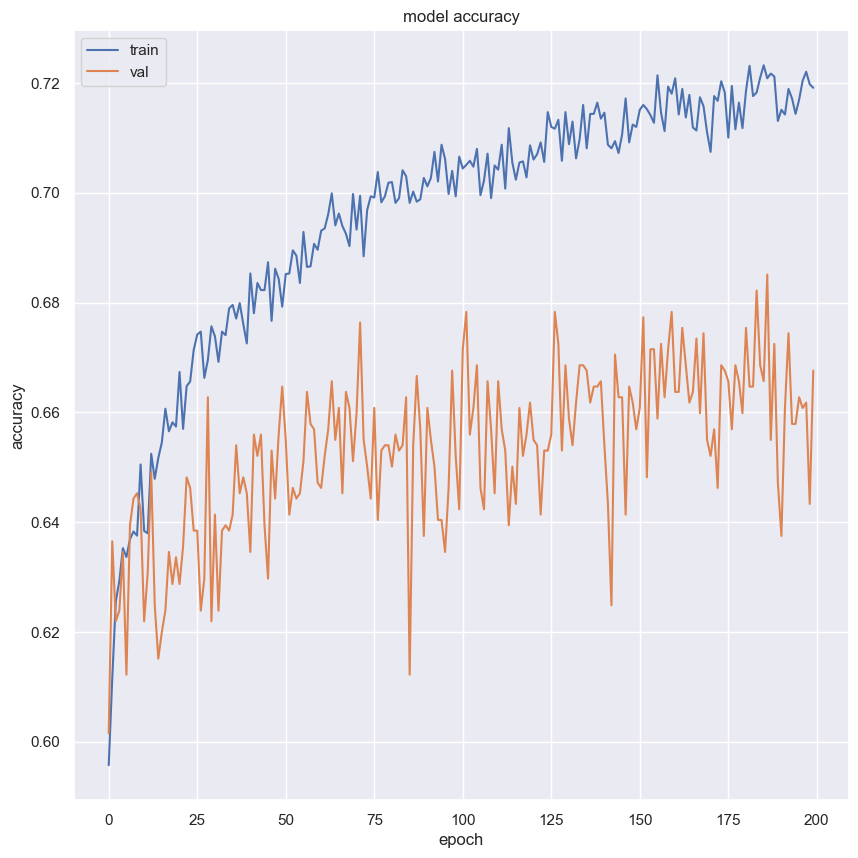

In [30]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

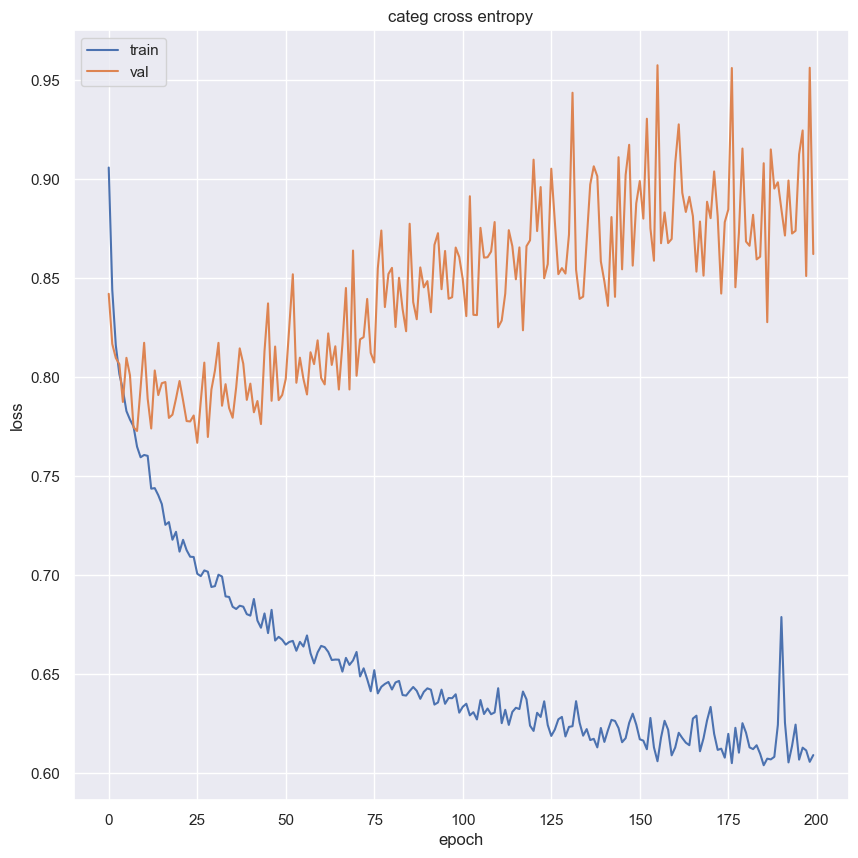

In [31]:
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('categ cross entropy')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

#Evaluate model on test data

In [32]:
# Evaluate your model accuracy on the test data
accuracy = model.evaluate(X_test,y_test)[1]

# Print accuracy
print('Accuracy:', accuracy)

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - accuracy: 0.6441 - loss: 0.9179
Accuracy: 0.6441073417663574


20/10/10/10 -> acc=0.654  
20/20/10 -> acc=0.632  
10/10/10/10/10 -> acc=0.642  
32/16/5 -> acc=0.645  
20/16/16/16 -> acc=0.6437  
32/16/16 -> acc=0.656  
32/16/16 (400 epochs) -> acc=0.6422  
32/16/8 -> acc=0.642

## Plot results

To draw a confusion matrix, we would need to go back from onehot encoding to class, we do that with .argmax method which finds which column has the highest score

In [15]:
from sklearn.metrics import confusion_matrix
from mlxtend.plotting import plot_confusion_matrix

# Get class probabilities and convert them to class ids
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

# y_test is already a 1D vector of class ids
confmatrix = confusion_matrix(y_test, y_pred_classes)

plot_confusion_matrix(conf_mat=confmatrix,
                                colorbar=True,
                                show_absolute=True,
                                show_normed=True,
                                cmap='viridis')

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 708us/step


ValueError: Classification metrics can't handle a mix of multilabel-indicator and multiclass targets